### Concepts shown in this demo notebook:

* Training a large PCTree on LLM token embeddings.
* Demonstrating / visualizing how each branch of a PCTree specializes in data.
* Deomonstrating compressing high dimensional data with PCTrees

**Things to try:**
* Reduce the `variance_capture_percent` parameter to 0.98 and see how that effects training.
* Try different `target_words` and see if there are branches that specialize in different concepts.
* Try different `max_width` and see how that effects compression performance.

## Imports

In [ ]:
import sys; sys.path.insert(0, "..") # don't need this line if package is installed. Need it if running from source.
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
sns.set_theme("paper", style="ticks")
mpl.rcParams['figure.dpi'] = 200
sns.set_palette("bright")

from pctree.core import PCTree, PCTreeCoefficients
from pctree.training import PCTreeTrainerOptions, PCTreeTrainer
from pctree.subspace_sifting import SubspaceSifterOptions
from pctree.branches import EfficientEncodingRouter
from pctree.pruning import MostVariancePruner
from pctree.reweighting import PCTreeReweighter
from pctree.io import save_pctree, load_pctree
from pctree.linalg_utils import my_full_svd

import warnings
warnings.filterwarnings('ignore')


## Load LLAMA 3 1B Token Embeddings

In [5]:
# token embedding numpy file and token label files available here:
# https://drive.google.com/drive/folders/106L_qpMxsybltzWJ_HnX1OYEUrCVmKdc
# This should be public, please contact benkizaric@gmail.com if you cant access.

In [ ]:
def load_token_labels(path: str):
    result = []
    with open(path) as f:
        result = [t.strip() for t in f.readlines()]
    return np.array(result)

token_emb = np.load("../data/llama/LLAMA_TOKEN_EMBEDDINGS.npy")
TOK = load_token_labels("../data/llama/LLAMA_TOKEN_LABELS.txt")
tok_emb_mean = token_emb.mean(axis=0)
token_emb = (token_emb - tok_emb_mean)

### Run SVD

In [4]:
U, s, VT = my_full_svd(token_emb)
cumulative_pca_variance = (s**2).cumsum() / (s**2).sum()

### Train PCT

In [ ]:
pct_training_options=PCTreeTrainerOptions(
    max_nodes=4000, 
    max_width=30,
    max_children=5,
    variance_capture_percent=0.997, # Try reducing this, this will accelatate training, especially partition training. 
    sifting_effect_size=0.75,
    pruner=MostVariancePruner(),
)

pct_trainer = PCTreeTrainer(pct_training_options)
pct_trainer.fit_partition(token_emb, verbose=1)
tree = pct_trainer.fit_em(token_emb, token_emb, n_iters=3, flex_tendrils=True, verbose=1)

Performing top-down partitioning to create initial PCT. 
Log Key: `-` is a node expanded by adding one additional child. `<` is a node expanded by spliting into two nodes. 
--<---<<<--<--<-<--<<<---<-----<---<--------<--<-<<-----<----<--<----<---------<-<--------<<-------<-----<----------------<-<
[Branch Assignment]|||||| 55089 points assigned in 15.68s. 
[Fixed-shape PCT Reweighting] ΣΣΣΣΣΣΣΣΣΣΣΣΣΣΣΣΣΣΣΣΣΣΣΣΣΣΣΣΣΣλλλλλλλλλλλλλλλλλλλλλλλλλλλλλλλλλλλλλλλλλλλλλλλλλλλλλλλ Reweighting using 55089 points in 24.38s. 
[Branch Assignment]|||||| 55089 points assigned in 7.09s. 
[Branch Assignment]|||||| 55089 points assigned in 7.2s. 


## Per-Branch Compression Performance

(Next Several Cells)

In [7]:
best_branch_for_data = EfficientEncodingRouter(tree, verbose=1).predict_batches(token_emb)
branches = tree.branches()

[Branch Assignment]|||||| 55089 points assigned in 8.38s. 


### Try different target cells

In [ ]:
is_target = np.zeros(token_emb.shape[0], dtype=bool)
target_words = ["north", "south", "east", "west"] # yes?
#target_words = ["a"]
for w in target_words:
    is_target[TOK == w] = True
is_target.sum()

77

Text(0.5, 0, 'Rank')

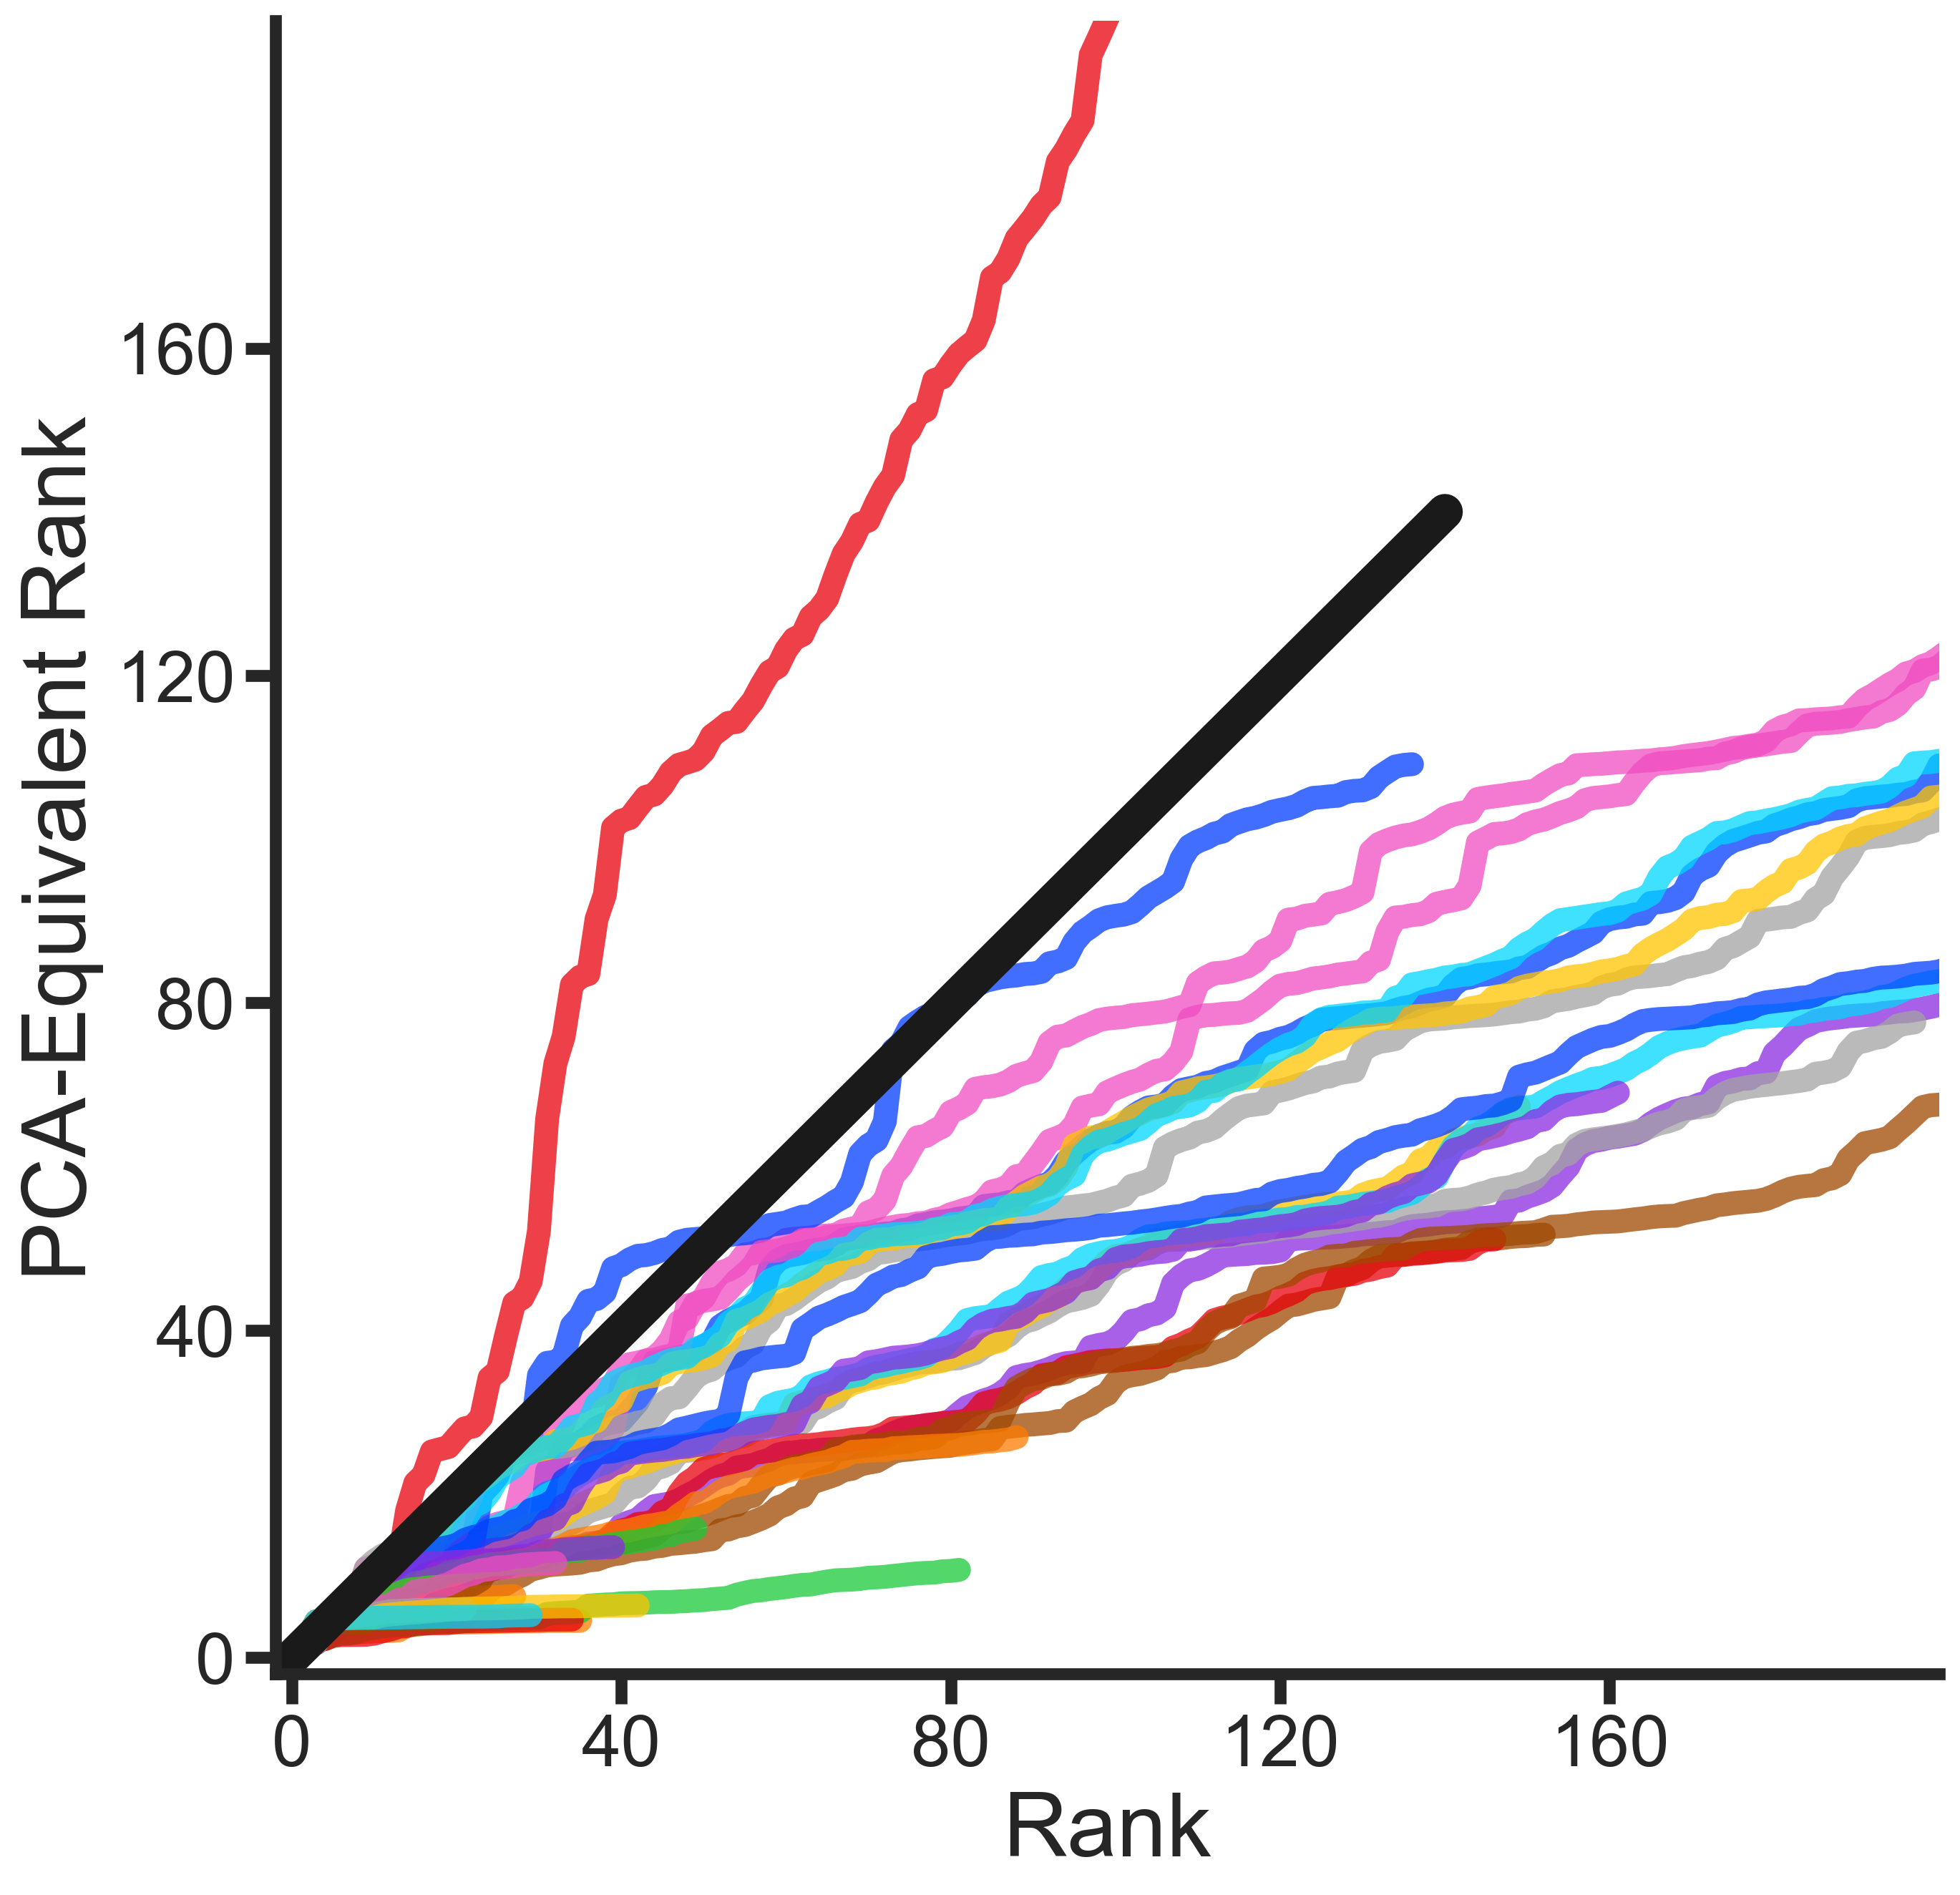

In [12]:
x = token_emb[is_target]

fig, ax1 = plt.subplots(figsize=(10, 10))
ax1.spines[['right', 'top']].set_visible(False)
ax1.tick_params(axis='both', which='major', labelsize=24, size=10, width=4)
ax1.set_xticks([0, 40, 80, 120, 160])
ax1.set_yticks([0, 40, 80, 120, 160])

ax1.spines["left"].set_linewidth(4)
ax1.spines["bottom"].set_linewidth(4)

PCA_DIM = 2000
pca_coeffs = (VT[:PCA_DIM] @ x.T).T
vv = (x**2).sum(axis=1).sum()
PCA_CUM = np.cumsum(pca_coeffs**2, axis=1).sum(axis=0) / vv
for idx, b in enumerate(branches):
    coeffs = (tree.V[b] @ x.T).T
    cumm_dots = (np.cumsum(coeffs**2, axis=1).sum(axis=0) / vv)
    equivilent_pca_rank = []
    equivilent_pca_rank = np.interp(cumm_dots, PCA_CUM, np.arange(len(PCA_CUM)))

    #if idx == 8:
    #    equivilent_pca_rank *= 0.85

    ax1.plot(np.arange(len(b)), equivilent_pca_rank, linewidth=8, alpha=0.75)
ax1.plot([0, 140], [0, 140], linewidth=12, alpha=1.0, c="k")
ax1.set_xlim(-2, 200)
ax1.set_ylim(-2, 200)
ax1.set_ylabel("PCA-Equivalent Rank", fontsize=30)
ax1.set_xlabel("Rank", fontsize=30)

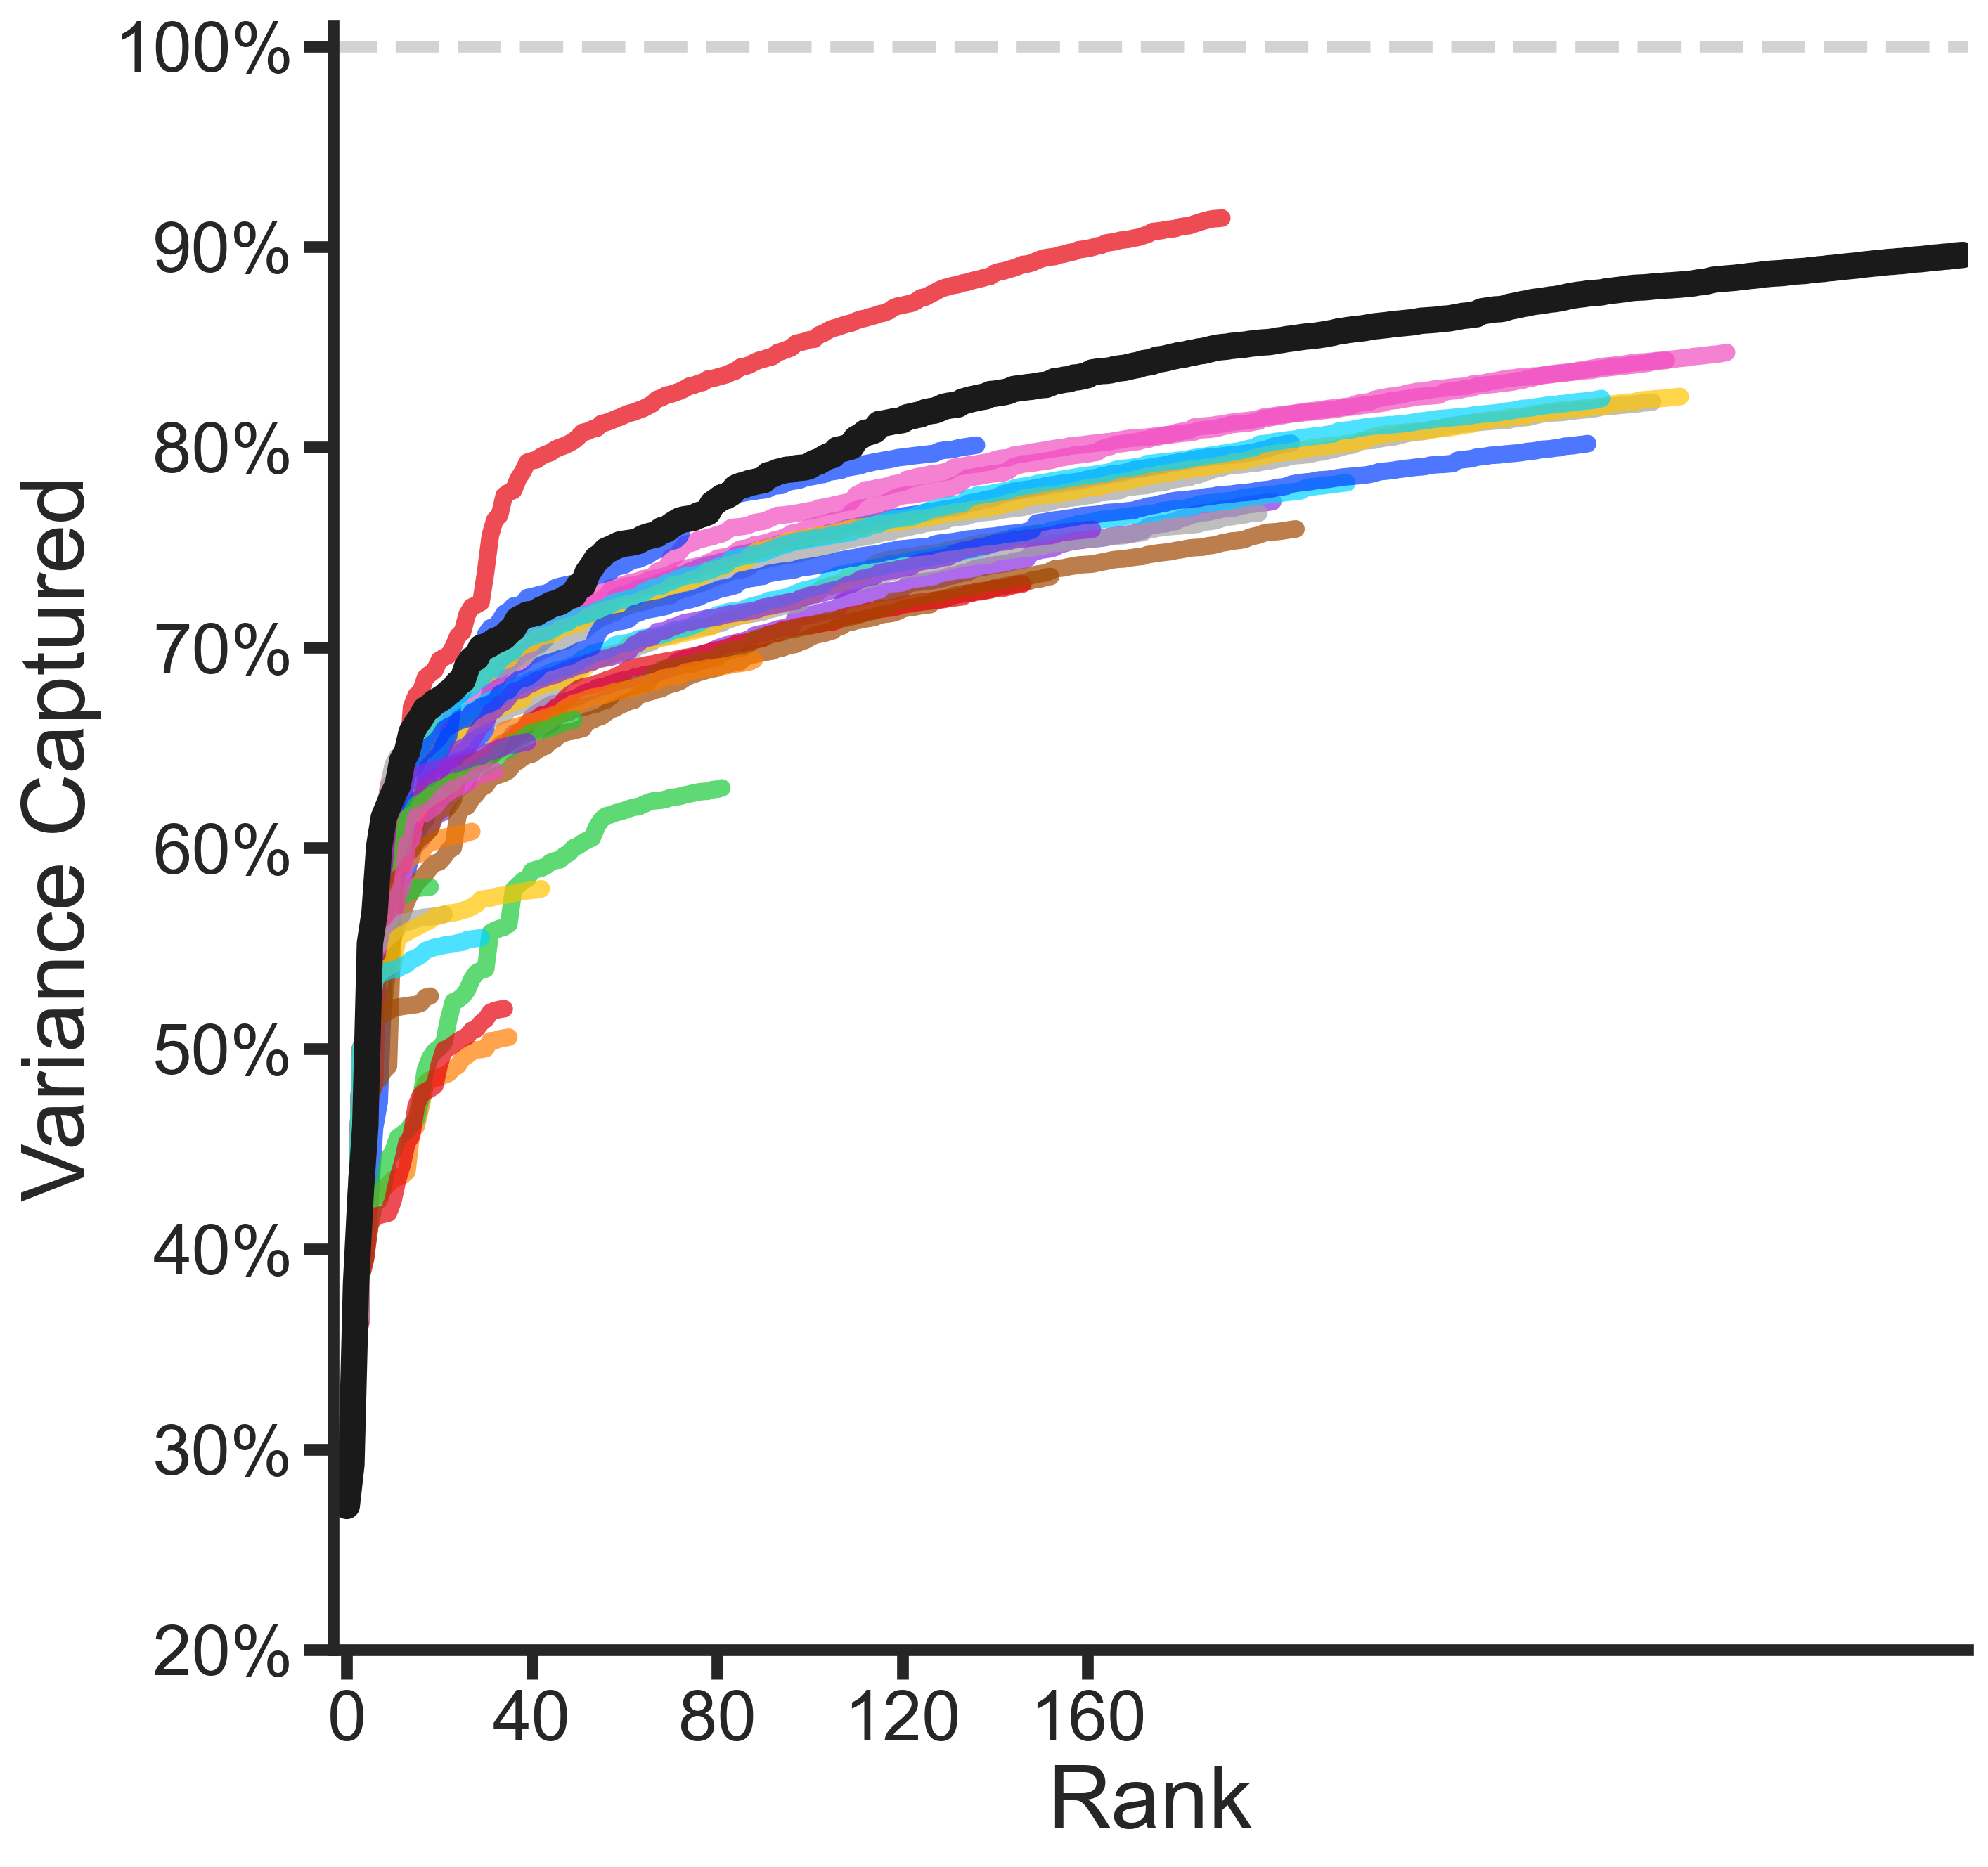

In [14]:
x = token_emb[is_target]

fig, ax1 = plt.subplots(figsize=(10, 10))
ax1.spines[['right', 'top']].set_visible(False)
ax1.tick_params(axis='both', which='major', labelsize=24, size=10, width=4)
ax1.spines["left"].set_linewidth(4)
ax1.spines["bottom"].set_linewidth(4)
ax1.set_yticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0], ["20%", "30%", "40%", "50%", "60%", "70%", "80%", "90%", "100%"])
ax1.set_xticks([0, 40, 80, 120, 160])

ax1.set_ylim(0.2, 1.01)
ax1.set_xlim(-3, 350)
PCA_DIM = 350
pca_coeffs = (VT[:PCA_DIM] @ x.T).T
vv = (x**2).sum(axis=1).sum()
PCA_CUM = np.cumsum(pca_coeffs**2, axis=1).sum(axis=0) / vv
for idx, b in enumerate(branches):
    coeffs = (tree.V[b] @ x.T).T
    cumm_dots = (np.cumsum(coeffs**2, axis=1).sum(axis=0) / vv) 
    ax1.plot(cumm_dots, linewidth=6, alpha=0.7)

ax1.set_ylabel("Variance Captured", fontsize=30)
ax1.set_xlabel("Rank", fontsize=30)
ax1.plot(PCA_CUM, linewidth=9, alpha=1, c="k")
ax1.axhline(1.0, c="lightgrey", linewidth=4, linestyle='--')

## Whole-Dataset Performance

(With current Tree)

In [15]:
branch_coeffs = PCTreeCoefficients(
    pct=tree,
    X=token_emb,
    branch_assignments=EfficientEncodingRouter(tree, verbose=1).predict_batches(token_emb),
)

token_emb_hat = branch_coeffs.reconstruct()

[Branch Assignment]|||||| 55089 points assigned in 8.05s. 


In [17]:
variance_captured = 1 - (((token_emb - token_emb_hat)**2).sum() / (token_emb**2).sum())
average_encoding_size = branch_coeffs.average_scalars_used()
equivilent_pca_encoding_size = np.interp(variance_captured, cumulative_pca_variance, np.arange(len(cumulative_pca_variance)))
print(f"{round(variance_captured * 100, 2)}% variance captured.")
print(f"Encoding data with a tree with {tree.N} nodes and {len(tree.branches())} branches.")
print(f"Average encoding size: {round(average_encoding_size, 2)} scalars. You would need {round(equivilent_pca_encoding_size, 2)} scalars to capture as much with PCA.")

95.9% variance captured.
Encoding data with a tree with 4000 nodes and 30 branches.
Average encoding size: 184.06 scalars. You would need 551.03 scalars to capture as much with PCA.


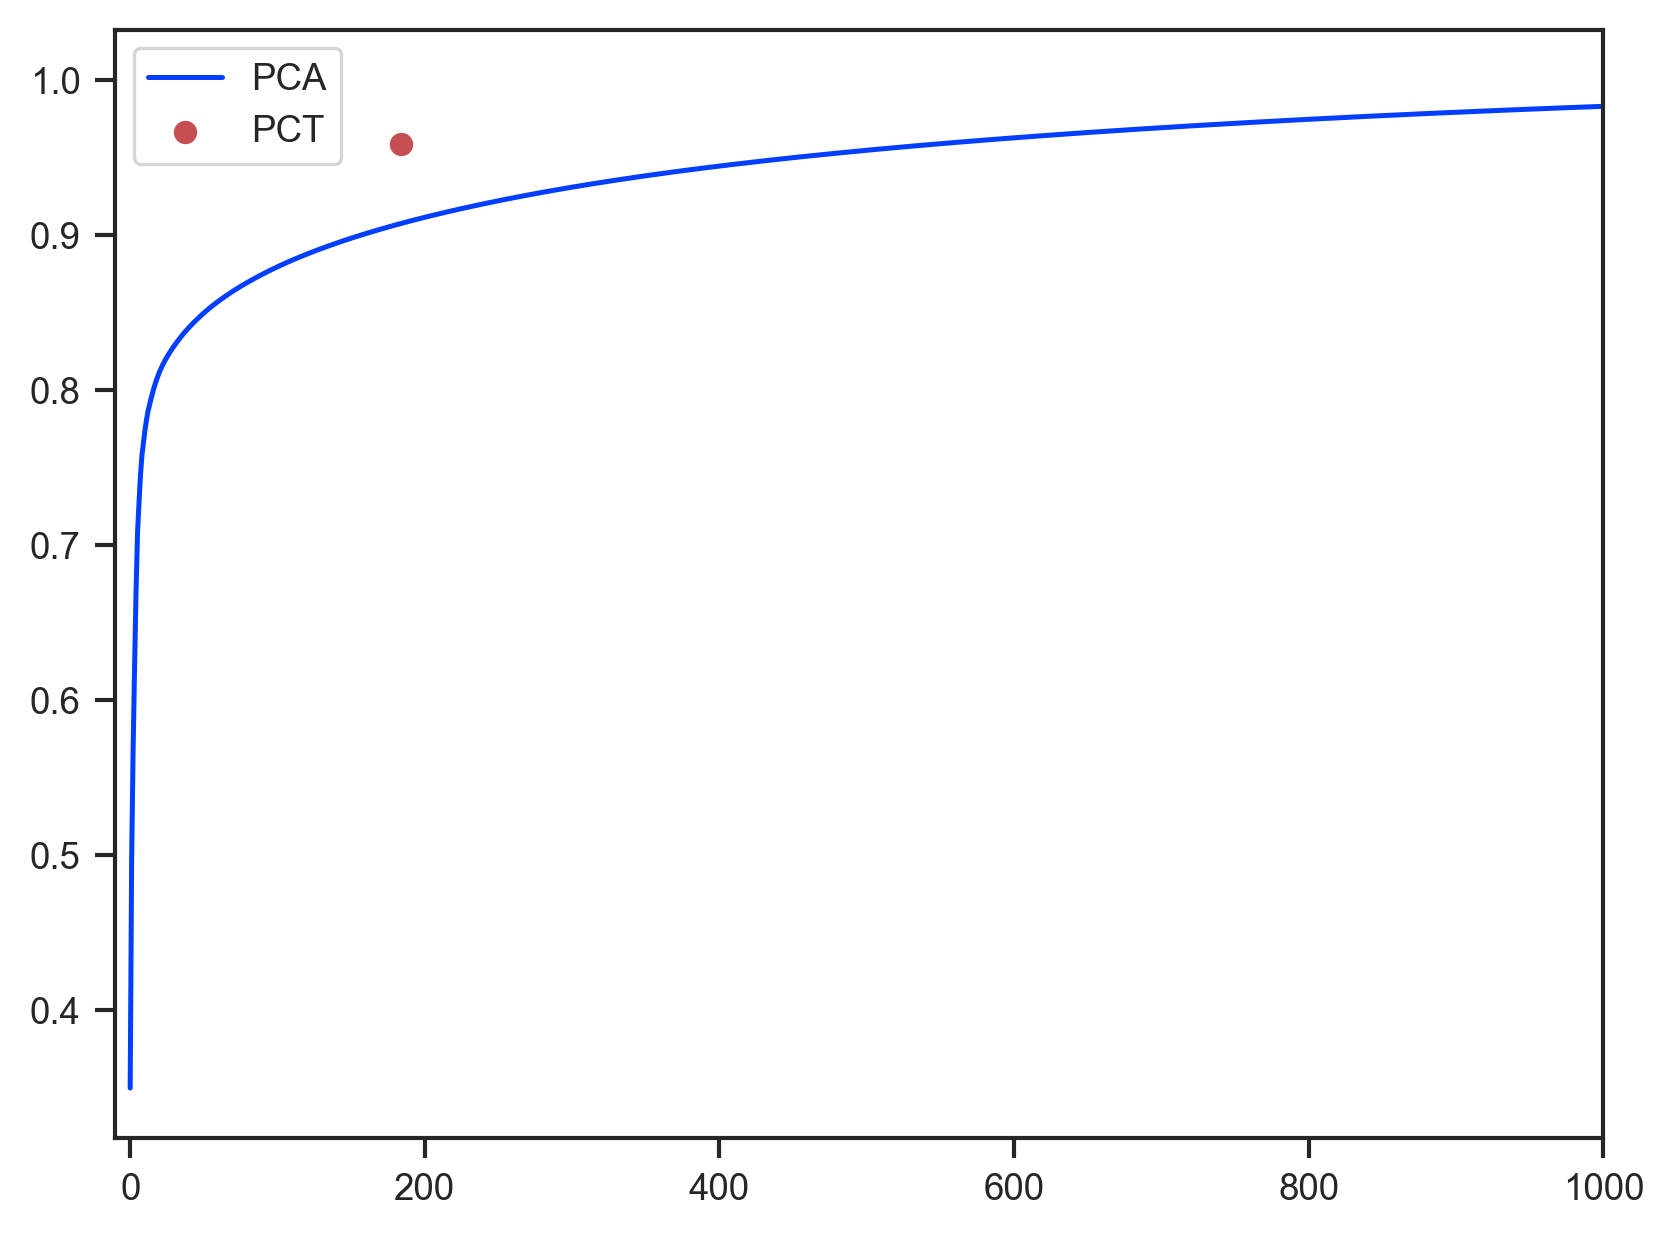

In [18]:
fig, ax = plt.subplots()
ax.plot(cumulative_pca_variance, label="PCA")
ax.set_xlim(-10, 1000)
ax.scatter([average_encoding_size], [variance_captured], c="r", label="PCT")
ax.legend()